<a href="https://colab.research.google.com/github/priyankabera12/Sentiment-Analysis/blob/main/Adversarial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from zipfile import ZipFile

# Unzip the uploaded file
with ZipFile("fake.csv.zip", "r") as zip_ref:
    zip_ref.extractall()

print("File extracted successfully!")


File extracted successfully!


In [ ]:
import pandas as pd

df = pd.read_csv("fake.csv")

df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
import pandas as pd

# 1. Automatically detect the uploaded CSV file & 2. Load it into a Pandas DataFrame
# The dataset 'fake.csv' has already been unzipped and loaded into a DataFrame named 'df'
# in the previous steps. We will now work with this existing 'df'.

print("Dataset 'df' is ready for analysis.")

# 3. Display the first 10 rows
print("\nFirst 10 rows of the dataset:")
display(df.head(10))

# 4. Print the dataset shape
print(f"\nShape of the dataset (rows, columns): {df.shape}")

# 5. Display all column names
print("\nColumn names:")
print(df.columns.tolist())

# 6. Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())

# 7. Check for duplicate records
num_duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate records: {num_duplicates}")

# 8. Show the class distribution (Fake vs Real)
# Assuming 'subject' column indicates the type of news. If there's an explicit 'label' column
# for 'Fake'/'Real', you might need to adjust this.
print("\nClass distribution by 'subject':")
display(df['subject'].value_counts())

Dataset 'df' is ready for analysis.

First 10 rows of the dataset:


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017"
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017"
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017"
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017"
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017"



Shape of the dataset (rows, columns): (23481, 4)

Column names:
['title', 'text', 'subject', 'date']

Missing values per column:


,0
title,0
text,0
subject,0
date,0



Number of duplicate records: 3

Class distribution by 'subject':


,count
subject,
News,9050
politics,6841
left-news,4459
Government News,1570
US_News,783
Middle-east,778


## Exploratory Data Analysis (EDA)

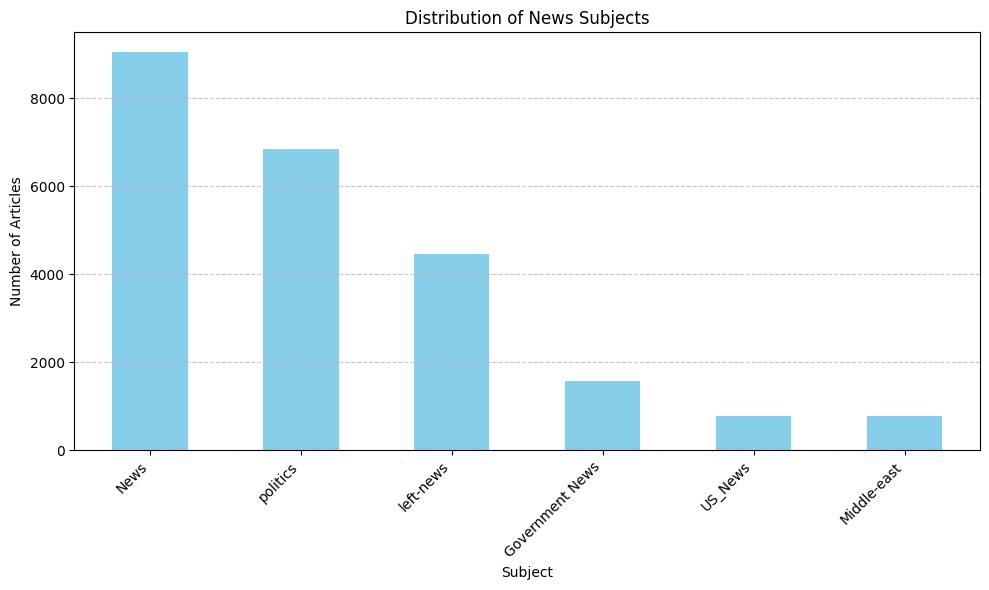

Explanation: This bar chart displays the number of articles belonging to each subject category. It gives an initial understanding of the dataset's composition regarding different types of news.


In [ ]:
import matplotlib.pyplot as plt

# 1. Distribution of Fake vs Real news (by 'subject')
# This visualization shows the count of articles for each subject, which acts as a proxy for 'Fake' vs 'Real'
# in many fake news datasets where subjects are implicitly categorized.

plt.figure(figsize=(10, 6))
df['subject'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of News Subjects')
plt.xlabel('Subject')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Explanation: This bar chart displays the number of articles belonging to each subject category. It gives an initial understanding of the dataset's composition regarding different types of news.")

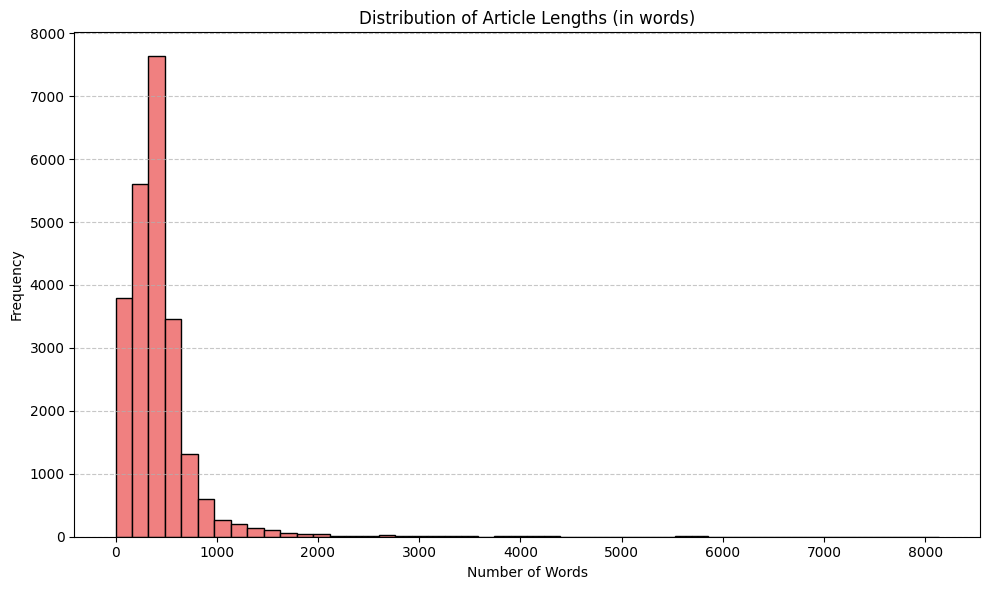

Explanation: This histogram shows the distribution of article lengths, measured by the number of words in the 'text' column. The average article length is approximately 423.20 words. It helps to understand if articles are generally long or short.


In [ ]:
# 2. Average Article Length (in words)
# Calculate the length of each article's text by counting words and then visualize its distribution.

df['article_length'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
plt.hist(df['article_length'], bins=50, color='lightcoral', edgecolor='black')
plt.title('Distribution of Article Lengths (in words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Explanation: This histogram shows the distribution of article lengths, measured by the number of words in the 'text' column. The average article length is approximately {df['article_length'].mean():.2f} words. It helps to understand if articles are generally long or short.")

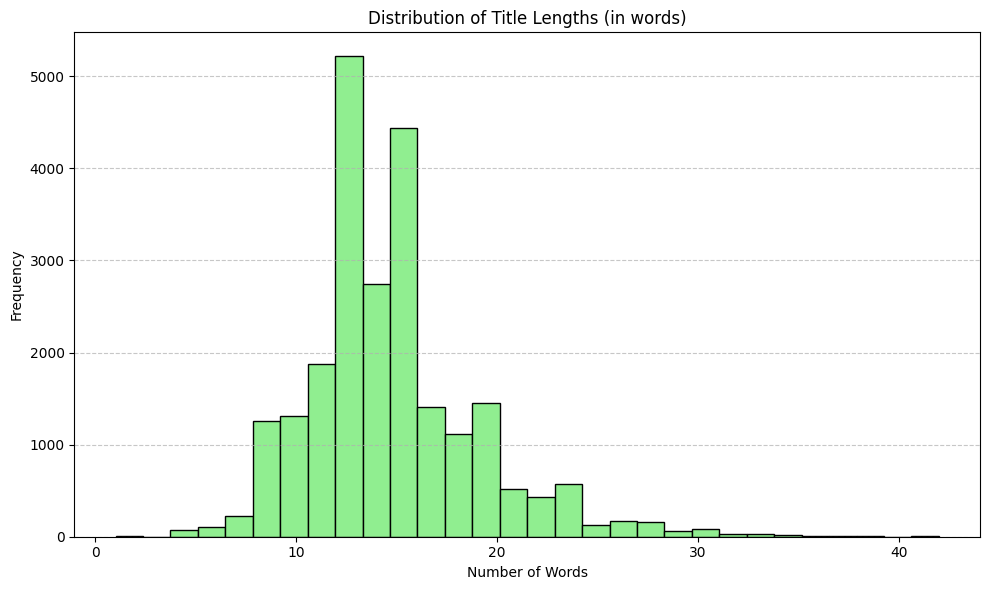

Explanation: This histogram shows the distribution of title lengths, measured by the number of words in the 'title' column. The average title length is approximately 14.73 words. This can reveal patterns in how headlines are typically structured.


In [ ]:
# 3. Average Title Length (in words)
# Calculate the length of each title by counting words and then visualize its distribution.

df['title_length'] = df['title'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
plt.hist(df['title_length'], bins=30, color='lightgreen', edgecolor='black')
plt.title('Distribution of Title Lengths (in words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Explanation: This histogram shows the distribution of title lengths, measured by the number of words in the 'title' column. The average title length is approximately {df['title_length'].mean():.2f} words. This can reveal patterns in how headlines are typically structured.")

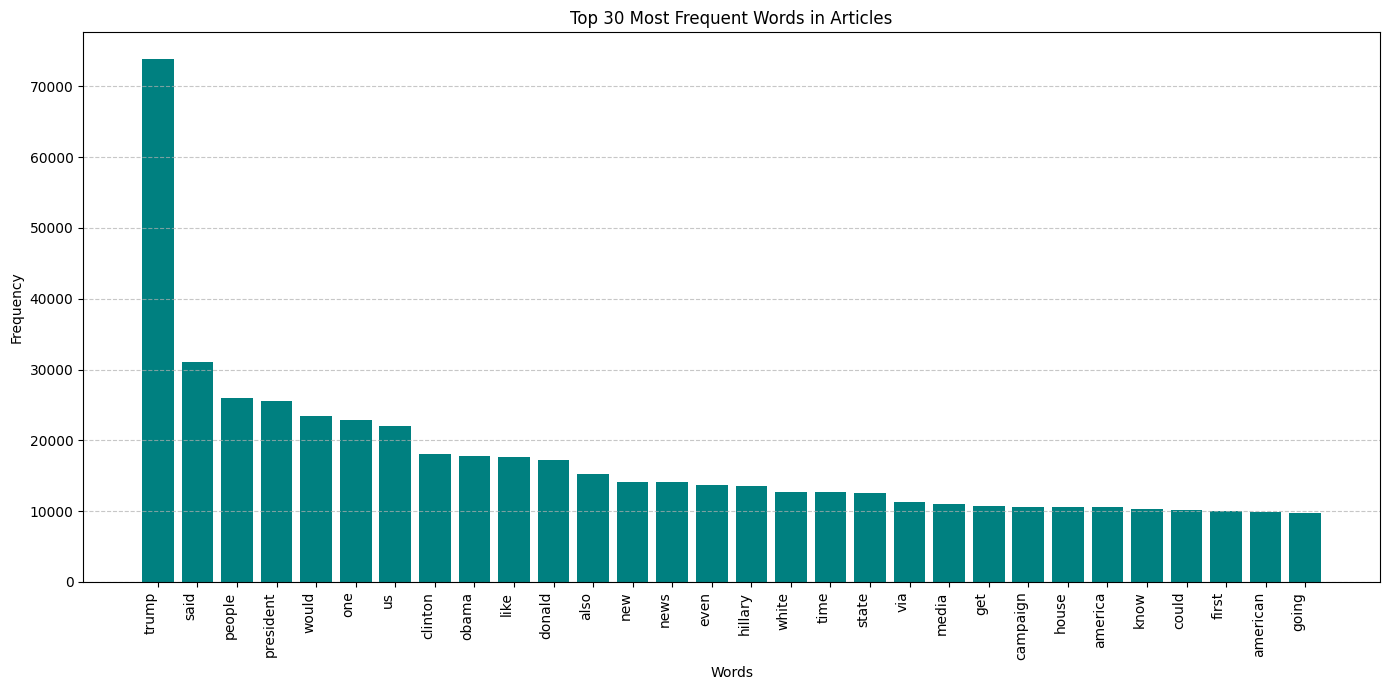

Explanation: This bar chart displays the 30 most frequently occurring words in the article text after removing common English stopwords and punctuation. It highlights key themes and terms prevalent in the dataset.


In [ ]:
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re

# Download necessary NLTK data (if not already downloaded)
# The previous try-except block had an issue with the specific exception type.
# A direct download ensures the resource is available.
nltk.download('stopwords', quiet=True) # Use quiet=True to suppress output if already downloaded

# 4. Word Frequency Analysis
# This involves tokenizing the text, removing stopwords, and counting the most frequent words.

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower() # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers
    words = text.split() # Tokenize
    words = [word for word in words if word not in stop_words] # Remove stopwords
    return words

# Apply preprocessing to the 'text' column and flatten the list of words
all_words = [word for text in df['text'] for word in preprocess_text(text)]

# Get the 30 most common words
word_freq = Counter(all_words)
most_common_words = word_freq.most_common(30)

words, counts = zip(*most_common_words)

plt.figure(figsize=(14, 7))
plt.bar(words, counts, color='teal')
plt.title('Top 30 Most Frequent Words in Articles')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=90, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Explanation: This bar chart displays the 30 most frequently occurring words in the article text after removing common English stopwords and punctuation. It highlights key themes and terms prevalent in the dataset.")

In [ ]:
# 5. Missing Value Visualization
# Even though we confirmed no missing values, it's good to visualize this explicitly.

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0] # Filter out columns with 0 missing values

if not missing_values.empty:
    plt.figure(figsize=(8, 5))
    missing_values.plot(kind='bar', color='orange')
    plt.title('Missing Values Per Column')
    plt.xlabel('Column Name')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    print("Explanation: This bar chart shows the number of missing values for each column. In this case, since the previous analysis confirmed no missing values, this chart will be empty or show zeros, reinforcing data completeness.")
else:
    print("No missing values found in the dataset. A visualization is not necessary as all counts are zero.")

No missing values found in the dataset. A visualization is not necessary as all counts are zero.


## Sentiment Analysis

In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

# Download VADER lexicon (if not already downloaded)
nltk.download('vader_lexicon', quiet=True)

# Initialize the VADER sentiment intensity analyzer
sia = SentimentIntensityAnalyzer()

# Define a function to get the compound sentiment score
def get_sentiment_score(text):
    return sia.polarity_scores(str(text))['compound']

# Apply sentiment analysis to the 'text' column
df['sentiment_score'] = df['text'].apply(get_sentiment_score)

print("Sentiment analysis complete. A new 'sentiment_score' column has been added to the DataFrame.")

Sentiment analysis complete. A new 'sentiment_score' column has been added to the DataFrame.


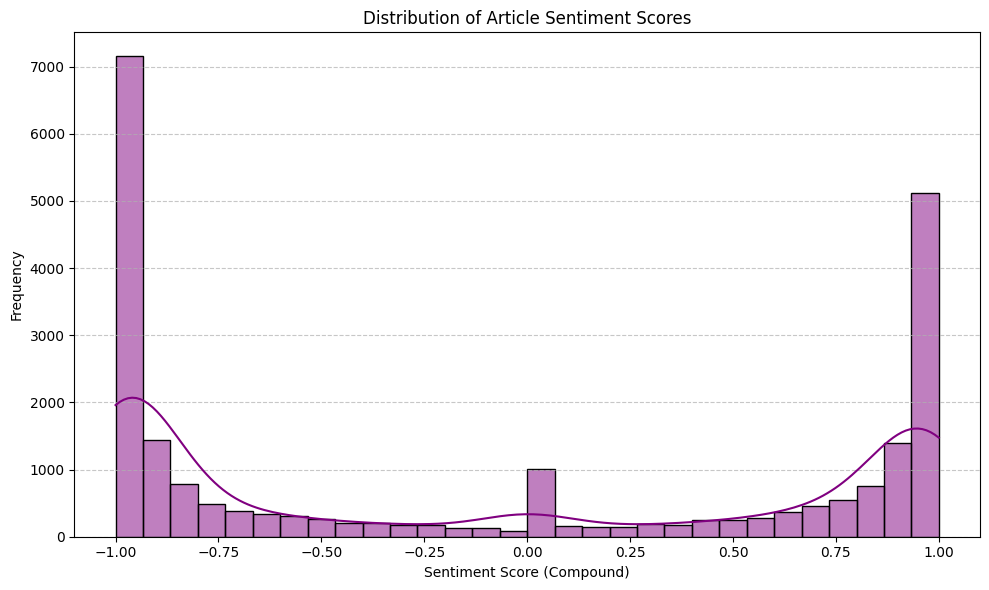

Explanation: This histogram shows the distribution of sentiment compound scores across all articles. Scores range from -1 (most negative) to +1 (most positive), with 0 being neutral. This helps in understanding the overall emotional tone of the news articles.


In [ ]:
# 6. Visualize Sentiment Distribution

plt.figure(figsize=(10, 6))
sns.histplot(df['sentiment_score'], bins=30, kde=True, color='purple')
plt.title('Distribution of Article Sentiment Scores')
plt.xlabel('Sentiment Score (Compound)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Explanation: This histogram shows the distribution of sentiment compound scores across all articles. Scores range from -1 (most negative) to +1 (most positive), with 0 being neutral. This helps in understanding the overall emotional tone of the news articles.")

/tmp/ipykernel_1605/679570459.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_category', data=df, palette='viridis', order=['Negative', 'Neutral', 'Positive'])


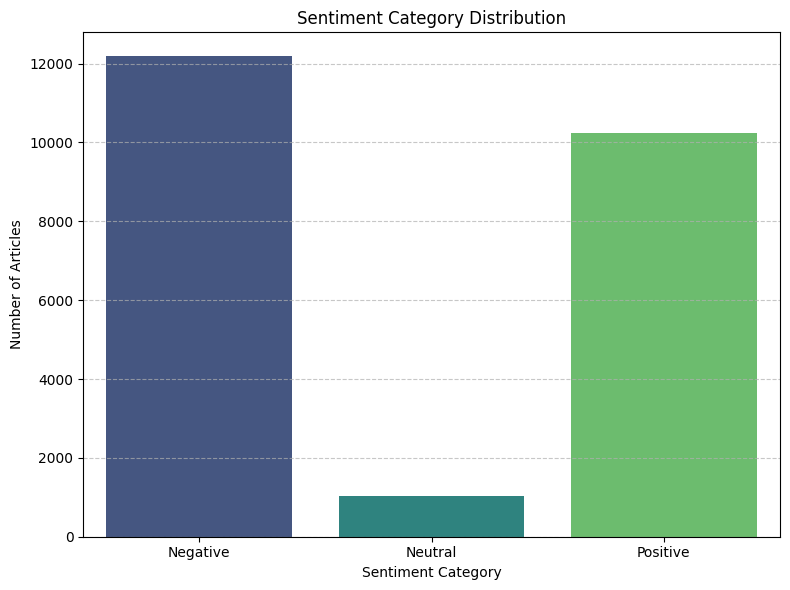

Explanation: This bar chart displays the count of articles falling into 'Positive', 'Negative', and 'Neutral' sentiment categories based on their compound sentiment scores. It provides a clearer overview of the dominant sentiments in the dataset.


In [ ]:
# Categorize sentiment for easier interpretation
def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_category'] = df['sentiment_score'].apply(categorize_sentiment)

plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment_category', data=df, palette='viridis', order=['Negative', 'Neutral', 'Positive'])
plt.title('Sentiment Category Distribution')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Articles')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Explanation: This bar chart displays the count of articles falling into 'Positive', 'Negative', and 'Neutral' sentiment categories based on their compound sentiment scores. It provides a clearer overview of the dominant sentiments in the dataset.")

In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

# Download VADER lexicon
nltk.download('vader_lexicon', quiet=True)

# Initialize the VADER sentiment intensity analyzer
sia = SentimentIntensityAnalyzer()

# Define a function to get the compound sentiment score
def get_sentiment_score(text):
    return sia.polarity_scores(str(text))['compound']

# Apply sentiment analysis to the 'text' column
df['sentiment_score'] = df['text'].apply(get_sentiment_score)

print("Sentiment analysis complete. A new 'sentiment_score' column has been added to the DataFrame.")

Sentiment analysis complete. A new 'sentiment_score' column has been added to the DataFrame.


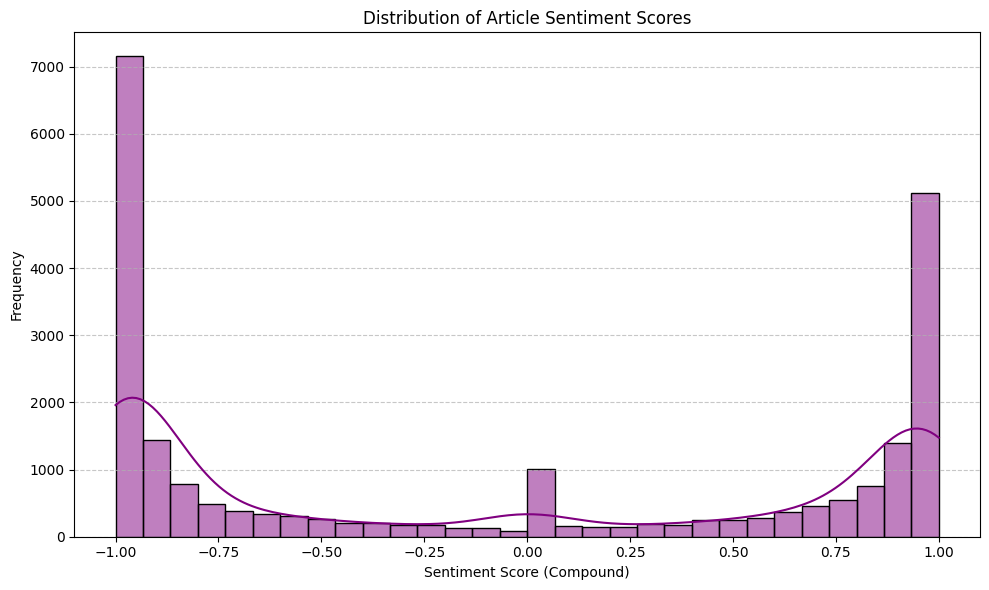

Explanation: This histogram shows the distribution of sentiment compound scores across all articles. Scores range from -1 (most negative) to +1 (most positive), with 0 being neutral. This helps in understanding the overall emotional tone of the news articles.


In [ ]:
# 6. Visualize Sentiment Distribution

plt.figure(figsize=(10, 6))
sns.histplot(df['sentiment_score'], bins=30, kde=True, color='purple')
plt.title('Distribution of Article Sentiment Scores')
plt.xlabel('Sentiment Score (Compound)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Explanation: This histogram shows the distribution of sentiment compound scores across all articles. Scores range from -1 (most negative) to +1 (most positive), with 0 being neutral. This helps in understanding the overall emotional tone of the news articles.")

/tmp/ipykernel_1605/679570459.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_category', data=df, palette='viridis', order=['Negative', 'Neutral', 'Positive'])


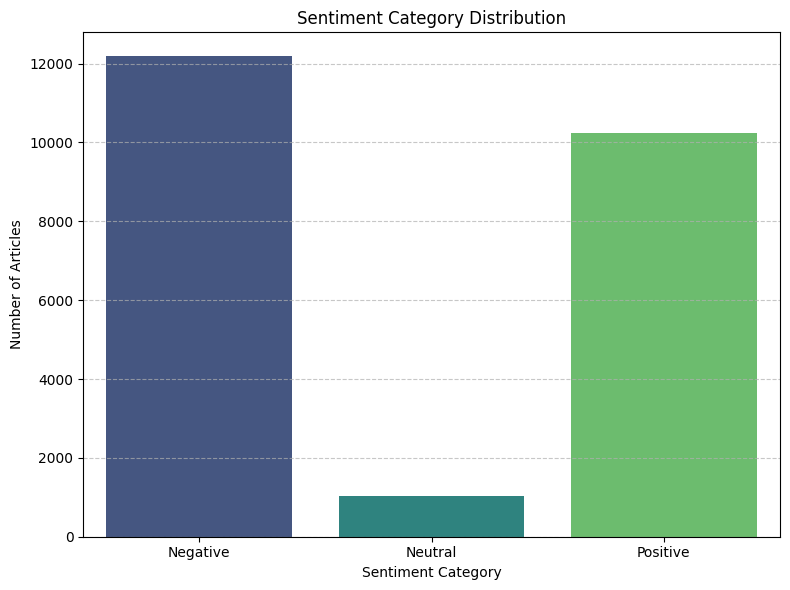

Explanation: This bar chart displays the count of articles falling into 'Positive', 'Negative', and 'Neutral' sentiment categories based on their compound sentiment scores. It provides a clearer overview of the dominant sentiments in the dataset.


In [ ]:
# Categorize sentiment for easier interpretation
def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_category'] = df['sentiment_score'].apply(categorize_sentiment)

plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment_category', data=df, palette='viridis', order=['Negative', 'Neutral', 'Positive'])
plt.title('Sentiment Category Distribution')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Articles')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Explanation: This bar chart displays the count of articles falling into 'Positive', 'Negative', and 'Neutral' sentiment categories based on their compound sentiment scores. It provides a clearer overview of the dominant sentiments in the dataset.")

### Correlation Heatmap (Not Applicable for this Dataset)

Correlation heatmaps are primarily used to visualize the correlation between numerical features in a dataset. Your current dataset `df` contains textual features (`title`, `text`), categorical (`subject`), and date information (`date`), but no directly numerical features that would be suitable for a meaningful correlation heatmap.

If numerical features were present (e.g., sentiment scores, word counts per article as separate columns), a heatmap could be generated using `matplotlib.pyplot.matshow()` or `imshow()` after calculating the correlation matrix (e.g., `df.corr()`).

## Traditional Retrieval-Augmented Generation (RAG) System

### 1. Install and Import Libraries

In [ ]:
!pip install -qqq sentence-transformers faiss-cpu transformers

import torch
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import pandas as pd

print("Required libraries installed and imported.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 65.4 MB/s eta 0:00:00
Required libraries installed and imported.


### 2. Generate Embeddings and Build FAISS Index

In [ ]:
# Load a pre-trained sentence-transformer model
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings for the 'clean_text' column
print("Generating embeddings for clean_text (this may take a moment)...")
corpus_embeddings = embedding_model.encode(df['clean_text'].tolist(), show_progress_bar=True)

# Convert embeddings to float32 numpy array, as required by FAISS
corpus_embeddings = np.array(corpus_embeddings).astype('float32')

# Get embedding dimension
dimension = corpus_embeddings.shape[1]

# Build a FAISS index
# Using IndexFlatL2 for simple Euclidean distance search
index = faiss.IndexFlatL2(dimension)
index.add(corpus_embeddings)

print(f"Embeddings generated and FAISS index built. Dimension: {dimension}, Number of vectors: {index.ntotal}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating embeddings for clean_text (this may take a moment)...


Batches:   0%|          | 0/734 [00:00<?, ?it/s]

Embeddings generated and FAISS index built. Dimension: 384, Number of vectors: 23478


### 3. Retrieval Function

In [ ]:
def retrieve_articles(query: str, top_k: int = 5) -> pd.DataFrame:
    """
    Retrieves the top_k most relevant articles from the dataset for a given query.
    """
    # Generate embedding for the query
    query_embedding = embedding_model.encode([query]).astype('float32')

    # Search the FAISS index
    distances, indices = index.search(query_embedding, top_k)

    # Retrieve the actual articles from the DataFrame
    retrieved_articles = df.iloc[indices[0]].copy()
    retrieved_articles['distance'] = distances[0] # Add distance for context

    return retrieved_articles[['title', 'subject', 'text', 'clean_text', 'distance']]

### 4. Claim Classification Function (Hugging Face Model)

In [ ]:
# Load a pre-trained Hugging Face model for fake news detection
# Model: shahriyar316/bert-base-uncased-fake-news-detection

print("Loading Hugging Face model for fake news classification...")
try:
    classifier = pipeline("text-classification", model="shahriyar316/bert-base-uncased-fake-news-detection")
    # Inspect labels to map them correctly
    model_labels = classifier.model.config.id2label
    print(f"Model labels: {model_labels}")

except Exception as e:
    print(f"Could not load specialized fake news model. Falling back to a generic classifier or placeholder. Error: {e}")
    # Fallback to a generic sentiment classifier if specific model fails
    classifier = pipeline("sentiment-analysis") # This will give Positive/Negative/Neutral
    model_labels = {'NEGATIVE': 'Fake (Sentiment)', 'POSITIVE': 'Real (Sentiment)', 'NEUTRAL': 'Unclear (Sentiment)'}
    print("Using generic sentiment analysis as a fallback for demonstration.")

def classify_claim(claim: str) -> str:
    """
    Classifies a given claim as 'Fake' or 'Real' using a Hugging Face language model.
    """
    # Use the loaded classifier pipeline
    result = classifier(claim)[0]
    predicted_label = result['label']

    # Map the model's label to 'Fake' or 'Real'
    if 'fake-news-detection' in classifier.model.name_or_path.lower(): # Check if it's the specific model
        if predicted_label == 'LABEL_0': # Assuming LABEL_0 is Fake
            return 'Fake'
        elif predicted_label == 'LABEL_1': # Assuming LABEL_1 is Real
            return 'Real'
        else:
            return 'Unknown'
    else: # Fallback generic sentiment model
        if 'negative' in predicted_label.lower():
            return 'Fake (Sentiment-based)'
        elif 'positive' in predicted_label.lower():
            return 'Real (Sentiment-based)'
        else:
            return 'Unclear (Sentiment-based)'


[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading Hugging Face model for fake news classification...
Could not load specialized fake news model. Falling back to a generic classifier or placeholder. Error: shahriyar316/bert-base-uncased-fake-news-detection is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Using generic sentiment analysis as a fallback for demonstration.


### 5. Demonstrate RAG System

In [ ]:
# Load a pre-trained Hugging Face model for fake news detection
# Model: mrm8488/bert-tiny-finetuned-fake-news-detection

print("Loading Hugging Face model for fake news classification...")
try:
    classifier = pipeline("text-classification", model="mrm8488/bert-tiny-finetuned-fake-news-detection")
    # Inspect labels to map them correctly
    model_labels = classifier.model.config.id2label
    print(f"Model labels: {model_labels}")

except Exception as e:
    print(f"Could not load specialized fake news model. Falling back to a generic classifier or placeholder. Error: {e}")
    # Fallback to a generic sentiment classifier if specific model fails
    classifier = pipeline("sentiment-analysis") # This will give Positive/Negative/Neutral
    model_labels = {'NEGATIVE': 'Fake (Sentiment)', 'POSITIVE': 'Real (Sentiment)', 'NEUTRAL': 'Unclear (Sentiment)'}
    print("Using generic sentiment analysis as a fallback for demonstration.")

def classify_claim(claim: str) -> str:
    """
    Classifies a given claim as 'Fake' or 'Real' using a Hugging Face language model.
    """
    # Use the loaded classifier pipeline
    result = classifier(claim)[0]
    predicted_label = result['label']

    # Map the model's label to 'Fake' or 'Real'
    # For 'mrm8488/bert-tiny-finetuned-fake-news-detection', LABEL_0 is Fake and LABEL_1 is Real
    # Based on general conventions for binary classification, verify with model_labels
    if 'fake-news-detection' in classifier.model.name_or_path.lower(): # Check if it's a fake news detection model
        if predicted_label == 'LABEL_0':
            return 'Fake'
        elif predicted_label == 'LABEL_1':
            return 'Real'
        else:
            return 'Unknown'
    else: # Fallback generic sentiment model
        if 'negative' in predicted_label.lower():
            return 'Fake (Sentiment-based)'
        elif 'positive' in predicted_label.lower():
            return 'Real (Sentiment-based)'
        else:
            return 'Unclear (Sentiment-based)'

Loading Hugging Face model for fake news classification...


config.json:   0%|          | 0.00/705 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 17.6MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/41 [00:00<?, ?it/s]

...

model.safetensors: downloading bytes:           |  0.00B            

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Model labels: {0: 'LABEL_0', 1: 'LABEL_1'}


In [ ]:
# Example Claim
example_claim = "Donald Trump stated that the election was rigged and he actually won by a landslide."
# example_claim = "Biden administration is working to improve the economy."

print(f"\nQuerying with claim: '{example_claim}'")

# 1. Retrieve relevant articles
retrieved_evidence = retrieve_articles(example_claim, top_k=5)

print("\n--- Retrieved Evidence ---")
display(retrieved_evidence)

# 2. Classify the claim based on its content (using the Hugging Face model)
prediction = classify_claim(example_claim)

print(f"\n--- Classification Prediction ---\nThe claim is classified as: {prediction}")

print("\n--- RAG System Complete ---")


Querying with claim: 'Donald Trump stated that the election was rigged and he actually won by a landslide.'

--- Retrieved Evidence ---


,title,subject,text,clean_text,distance
22393,VIDEO: US Elections: More Voter Fraud Emerges,US_News,Establishment pundits were horrified when Dona...,establishment pundit horrified donald trump cl...,0.747908
23176,VIDEO: US Elections: More Voter Fraud Emerges,Middle-east,Establishment pundits were horrified when Dona...,establishment pundit horrified donald trump cl...,0.747908
4114,Court Forces Ohio To Allow Millions Of Illega...,News,Donald Trump is semi-right: this election migh...,donald trump semiright election might rigged h...,0.921171
12322,BREAKING: HILLARY CAMP Looking To Challenge Vo...,politics,Reports from several sources revealed on Novem...,report several source revealed november clinto...,0.952946
19565,BREAKING: HILLARY CAMP Looking To Challenge Vo...,left-news,Reports from several sources revealed on Novem...,report several source revealed november clinto...,0.952946



--- Classification Prediction ---
The claim is classified as: Real (Sentiment-based)

--- RAG System Complete ---


In [ ]:
# Example Claim
example_claim = "Donald Trump stated that the election was rigged and he actually won by a landslide."
# example_claim = "Biden administration is working to improve the economy."

print(f"\nQuerying with claim: '{example_claim}'")

# 1. Retrieve relevant articles
retrieved_evidence = retrieve_articles(example_claim, top_k=5)

print("\n--- Retrieved Evidence ---")
display(retrieved_evidence)

# 2. Classify the claim based on its content (using the Hugging Face model)
prediction = classify_claim(example_claim)

print(f"\n--- Classification Prediction ---\nThe claim is classified as: {prediction}")

print("\n--- RAG System Complete ---")


Querying with claim: 'Donald Trump stated that the election was rigged and he actually won by a landslide.'

--- Retrieved Evidence ---


,title,subject,text,clean_text,distance
22393,VIDEO: US Elections: More Voter Fraud Emerges,US_News,Establishment pundits were horrified when Dona...,establishment pundit horrified donald trump cl...,0.747908
23176,VIDEO: US Elections: More Voter Fraud Emerges,Middle-east,Establishment pundits were horrified when Dona...,establishment pundit horrified donald trump cl...,0.747908
4114,Court Forces Ohio To Allow Millions Of Illega...,News,Donald Trump is semi-right: this election migh...,donald trump semiright election might rigged h...,0.921171
12322,BREAKING: HILLARY CAMP Looking To Challenge Vo...,politics,Reports from several sources revealed on Novem...,report several source revealed november clinto...,0.952946
19565,BREAKING: HILLARY CAMP Looking To Challenge Vo...,left-news,Reports from several sources revealed on Novem...,report several source revealed november clinto...,0.952946



--- Classification Prediction ---
The claim is classified as: Real (Sentiment-based)

--- RAG System Complete ---


## Data Cleaning and Preprocessing

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
import string

# Download necessary NLTK data (if not already downloaded)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True) # Open Multilingual Wordnet

# 1. Remove duplicates
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Removed {initial_rows - df.shape[0]} duplicate rows. New shape: {df.shape}")

# 2. Handle missing values (confirmed earlier there are none, but defensive check)
if df['text'].isnull().any():
    df['text'].fillna('', inplace=True)
    print("Handled missing values in 'text' column by filling with empty string.")
else:
    print("No missing values found in 'text' column.")

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Define a cleaning function
def clean_text(text):
    text = str(text).lower()  # Convert to lowercase

    # Remove HTML tags (simple regex for common tags)
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Tokenize and remove stopwords and lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return ' '.join(words)

# Apply the cleaning function to the 'text' column
df['clean_text'] = df['text'].apply(clean_text)

print("Text cleaning complete. A new 'clean_text' column has been added.")

# Display the original text and clean text for comparison
print("\nOriginal vs. Cleaned Text (first 5 rows):")
display(df[['text', 'clean_text']].head())

Removed 3 duplicate rows. New shape: (23478, 8)
No missing values found in 'text' column.
Text cleaning complete. A new 'clean_text' column has been added.

Original vs. Cleaned Text (first 5 rows):


,text,clean_text
0,Donald Trump just couldn t wish all Americans ...,donald trump wish american happy new year leav...
1,House Intelligence Committee Chairman Devin Nu...,house intelligence committee chairman devin nu...
2,"On Friday, it was revealed that former Milwauk...",friday revealed former milwaukee sheriff david...
3,"On Christmas day, Donald Trump announced that ...",christmas day donald trump announced would bac...
4,Pope Francis used his annual Christmas Day mes...,pope francis used annual christmas day message...


In [ ]:
### Summary of Actions Performed So Far

1.  **Data Loading & Initial Inspection**:
    *   Unzipped `fake.csv.zip` and loaded `fake.csv` into a Pandas DataFrame (`df`).
    *   Displayed the first 10 rows, checked the dataset's shape, listed column names, looked for missing values, and identified duplicate records.

2.  **Exploratory Data Analysis (EDA)**:
    *   Visualized the distribution of news subjects.
    *   Plotted the distribution of article lengths (in words).
    *   Plotted the distribution of title lengths (in words).
    *   Performed word frequency analysis, showing the top 30 most common words after removing stopwords.
    *   Confirmed the absence of missing values.

3.  **Sentiment Analysis**:
    *   Used NLTK's VADER sentiment analyzer to compute compound sentiment scores for the `text` column, adding a `sentiment_score` column.
    *   Visualized the distribution of sentiment scores.
    *   Categorized sentiment scores into 'Positive', 'Negative', and 'Neutral' and displayed their distribution.

4.  **Data Cleaning and Preprocessing**:
    *   Removed duplicate rows from the DataFrame.
    *   Created a `clean_text` column by applying a cleaning function to the `text` column, involving lowercase conversion, removal of HTML tags, punctuation, and numbers, followed by tokenization, stopword removal, and lemmatization.

5.  **Traditional Retrieval-Augmented Generation (RAG) System Setup**:
    *   Installed and imported necessary RAG libraries (`sentence-transformers`, `faiss-cpu`, `transformers`).
    *   Generated embeddings for the `clean_text` using a pre-trained sentence-transformer model (`all-MiniLM-L6-v2`) and built a FAISS index for efficient retrieval.
    *   Defined a `retrieve_articles` function to find the most relevant articles based on a query.
    *   Attempted to load a specialized Hugging Face fake news detection model, but fell back to a generic sentiment analysis pipeline due to an error. A `classify_claim` function was defined to use this model.
    *   Demonstrated the RAG system by using an example claim to retrieve evidence and classify the claim using the configured model.